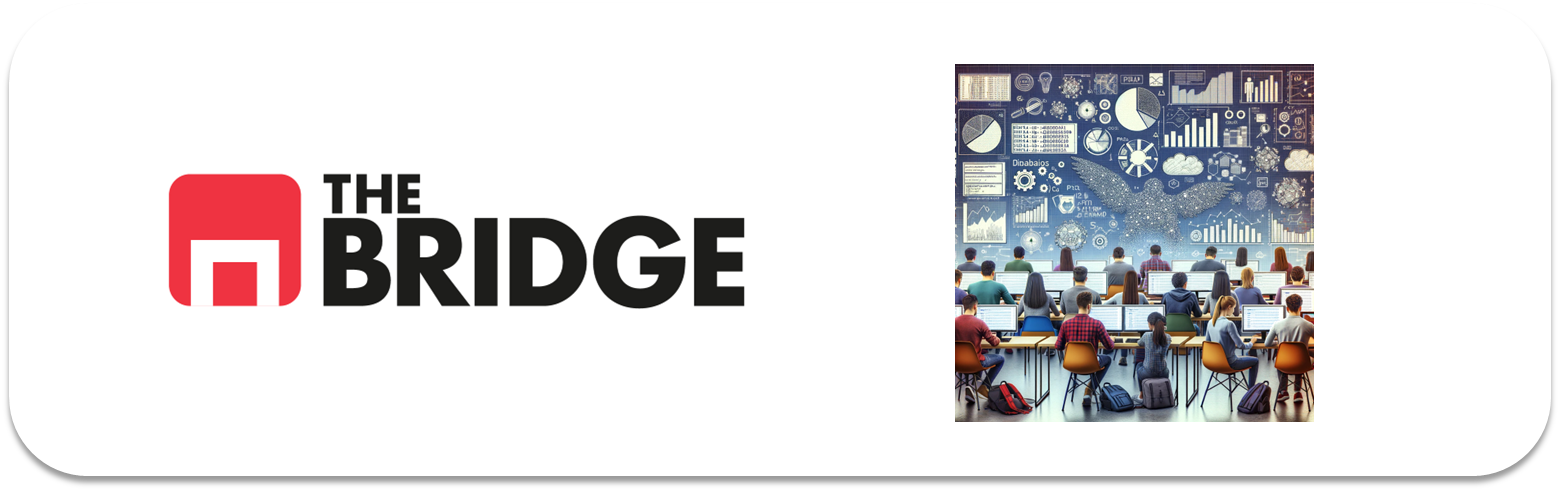

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, accuracy_score
)
from sklearn.impute import SimpleImputer
import bootcampviztools as bz


1. Carga del dataset

In [2]:
df_titanic = pd.read_csv('data/titanic.csv')

df = df_titanic.copy()

In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [5]:
# paso de Juan

df.select_dtypes(include=['int64', 'float64']).columns.tolist()

df.select_dtypes(include=['str', 'bool']).columns.tolist()

['sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [6]:
print(df.select_dtypes(include=['int64', 'float64']).describe())

print("-----------------------------------------------------------------------------")

print(df.select_dtypes(include=['str', 'bool']).describe())


         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200
-----------------------------------------------------------------------------
         sex embarked  class  who adult_male deck  embark_town alive alone
count    891      889    891  891        891  203          889   891   891
unique     2        3      3    3          2    7            3     2  

2. Limpieza

In [7]:
target = 'survived'


excluir = ['embark_town', 'alive', 'class','adult']

In [8]:
df_deck = df.copy()
df_deck["deck"] = df_deck.deck.fillna ("UNK")
df_deck.deck.value_counts(normalize=True)

deck
UNK    0.772166
C      0.066218
B      0.052750
D      0.037037
E      0.035915
A      0.016835
F      0.014590
G      0.004489
Name: proportion, dtype: float64

In [9]:
# paso de Juan

features_base = [col for col in df_deck.columns if col not in excluir]
features_base.remove("deck")

features_base_deck = [col for col in df_deck.columns if col not in excluir]

In [10]:
df_deck["embarked"].value_counts(normalize=True, dropna=False)

embarked
S      0.722783
C      0.188552
Q      0.086420
NaN    0.002245
Name: proportion, dtype: float64

In [11]:
df_deck = df_deck.dropna(subset=['embarked'])

In [12]:
df_deck["embarked"].value_counts(normalize=True, dropna=False)

embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64

3. Análisis univariable

C:\Users\User\AppData\Local\Temp\ipykernel_27080\1465667450.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='sex', y='survived', ax=axes[1],
C:\Users\User\AppData\Local\Temp\ipykernel_27080\1465667450.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='pclass', y='survived', ax=axes[2],


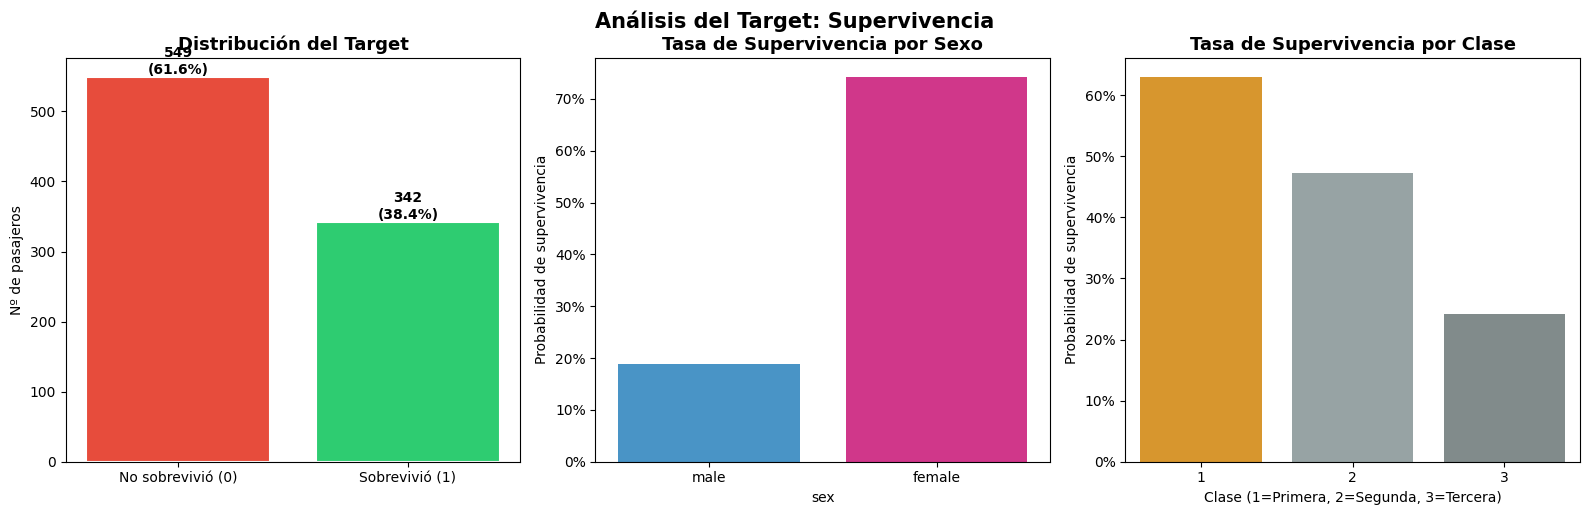


📊 Análisis de la distribución del target:
  - Clase NEGATIVA (No sobrevivió): 549 (61.6%)
  - Clase POSITIVA (Sobrevivió):    342 (38.4%)

⚠️  El dataset está moderadamente desbalanceado (~62% vs ~38%).
    Esto significa que un modelo que siempre prediga "no sobrevive"
    tendría ya un 62% de accuracy. Debemos fijarnos más en F1, recall y AUC.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución del target
counts = df['survived'].value_counts()
axes[0].bar(['No sobrevivió (0)', 'Sobrevivió (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución del Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nº de pasajeros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Supervivencia por sexo
sns.barplot(data=df, x='sex', y='survived', ax=axes[1],
            palette=['#3498db', '#e91e8c'], errorbar=None)
axes[1].set_title('Tasa de Supervivencia por Sexo', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Probabilidad de supervivencia')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Supervivencia por clase
sns.barplot(data=df, x='pclass', y='survived', ax=axes[2],
            palette=['#f39c12', '#95a5a6', '#7f8c8d'], errorbar=None)
axes[2].set_title('Tasa de Supervivencia por Clase', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Probabilidad de supervivencia')
axes[2].set_xlabel('Clase (1=Primera, 2=Segunda, 3=Tercera)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.suptitle('Análisis del Target: Supervivencia', y=1.02, fontsize=15, fontweight='bold')
plt.show()

print('\n📊 Análisis de la distribución del target:')
print(f'  - Clase NEGATIVA (No sobrevivió): {counts[0]} ({counts[0]/len(df)*100:.1f}%)')
print(f'  - Clase POSITIVA (Sobrevivió):    {counts[1]} ({counts[1]/len(df)*100:.1f}%)')
print()
print('⚠️  El dataset está moderadamente desbalanceado (~62% vs ~38%).')
print('    Esto significa que un modelo que siempre prediga "no sobrevive"')
print('    tendría ya un 62% de accuracy. Debemos fijarnos más en F1, recall y AUC.')

4. Split en train y test y emparejamiento

In [14]:
train_set, test_set = train_test_split(df_deck, test_size= 0.2, random_state=73, stratify=df_deck["embarked"])

In [15]:
train_set["embarked"].value_counts(normalize = True)

embarked
S    0.724332
C    0.188467
Q    0.087201
Name: proportion, dtype: float64

In [16]:
test_set["embarked"].value_counts(normalize = True)

embarked
S    0.724719
C    0.191011
Q    0.084270
Name: proportion, dtype: float64

In [17]:
#train_set.info()

6. Imputación de medianas

In [18]:
#paso de Juan

es_hombre = train_set.who == "man"
es_mujer = train_set.who == "woman"
es_child = train_set.who == "child"

median_man = train_set[es_hombre]["age"].median()
median_woman = train_set[es_mujer]["age"].median()
median_child = train_set[es_child]["age"].median()

es_nulo = train_set.age.isna()
es_nulo_test = test_set.age.isna()

# Imputamos en train
train_set.loc[es_hombre & es_nulo, "age"] = median_man
train_set.loc[es_mujer & es_nulo, "age"] = median_woman
train_set.loc[es_child & es_nulo, "age"] = median_child

# Imputamos en test
test_set.loc[(test_set.who == "man") & es_nulo_test, "age"] = median_man
test_set.loc[(test_set.who == "woman") & es_nulo_test, "age"] = median_woman
test_set.loc[(test_set.who == "child") & es_nulo_test, "age"] = median_child

7. MiniEda

In [19]:
train_set[target].value_counts(normalize=True)

survived
0    0.620253
1    0.379747
Name: proportion, dtype: float64

In [20]:
train_set[features_base_deck].info()

<class 'pandas.DataFrame'>
Index: 711 entries, 455 to 162
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    711 non-null    int64  
 1   pclass      711 non-null    int64  
 2   sex         711 non-null    str    
 3   age         711 non-null    float64
 4   sibsp       711 non-null    int64  
 5   parch       711 non-null    int64  
 6   fare        711 non-null    float64
 7   embarked    711 non-null    str    
 8   who         711 non-null    str    
 9   adult_male  711 non-null    bool   
 10  deck        711 non-null    str    
 11  alone       711 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(4)
memory usage: 62.5 KB


In [21]:
features_num = ['age','fare','sibsp', 'parch']

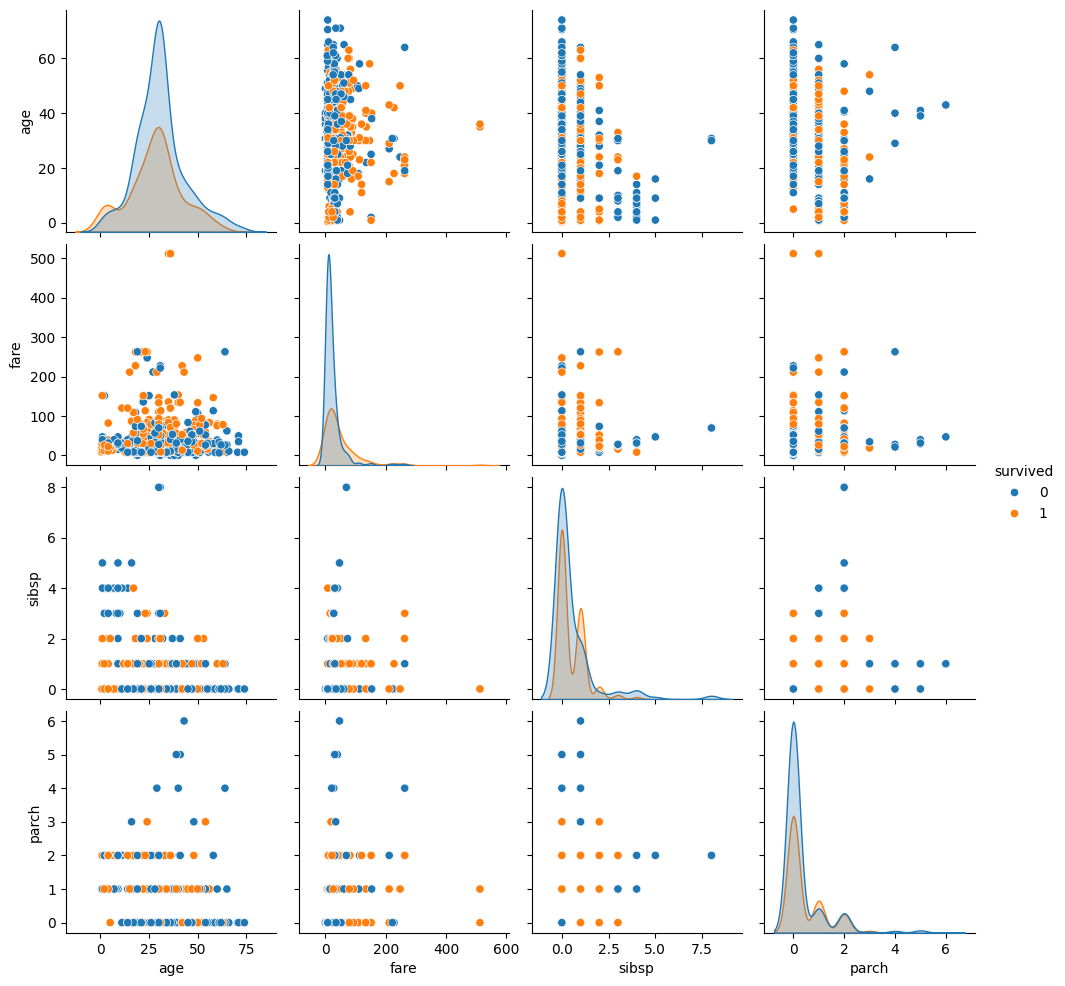

In [22]:
sns.pairplot(
    train_set[features_num + ['survived']],
    hue='survived'
)

In [23]:
features_num = ["fare", "age", "sibsp"]


In [24]:
features_cat = ["pclass", "sex", "embarked", "alone", "who", "deck"]

In [25]:
train_set["deck_informed"] = train_set["deck"] != "UNK"
test_set["deck_informed"] = test_set["deck"] != "UNK"

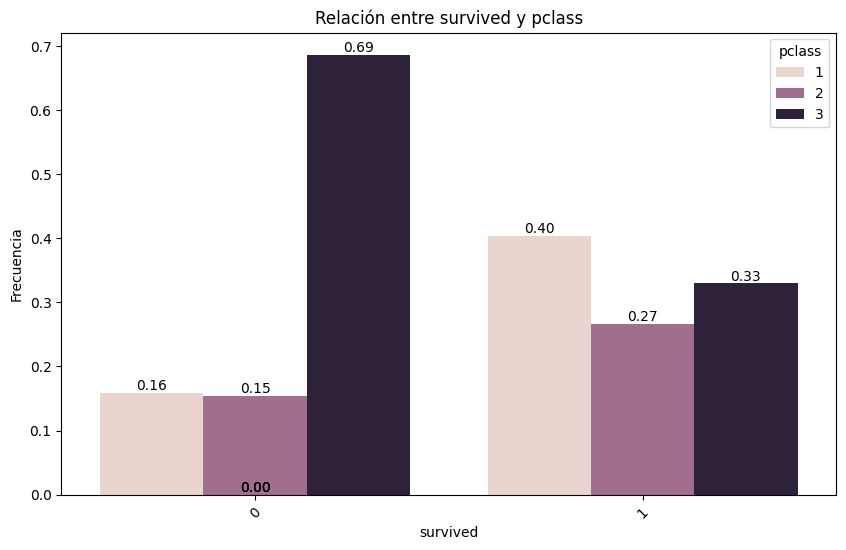

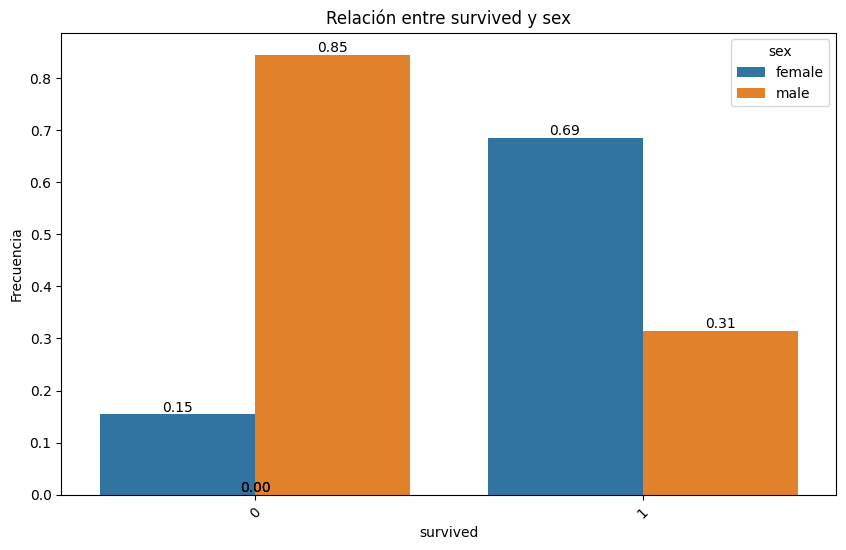

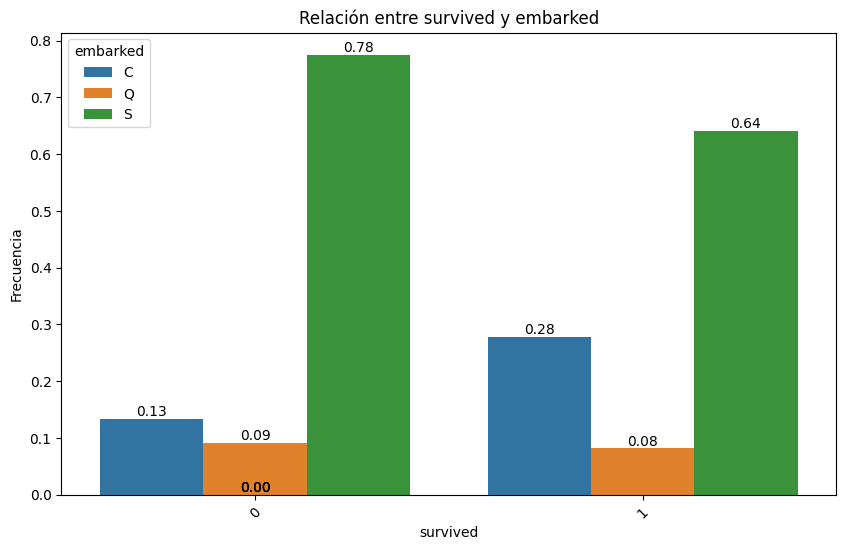

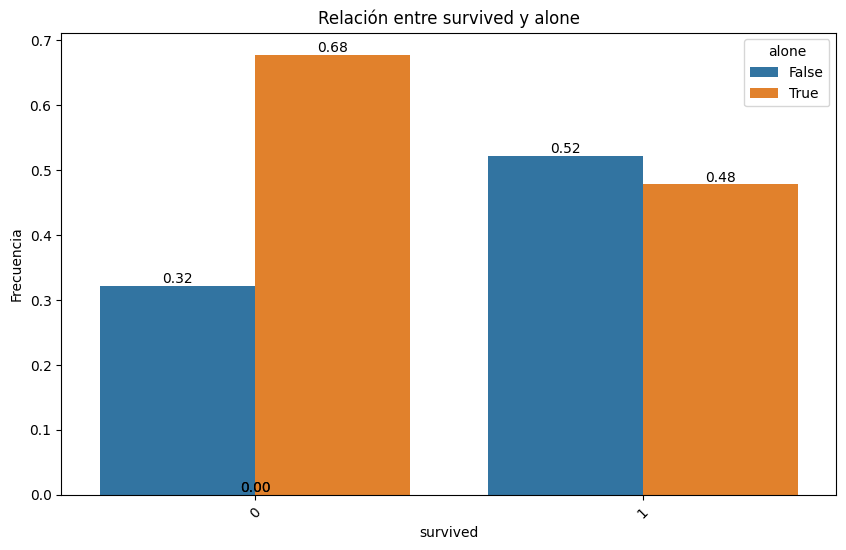

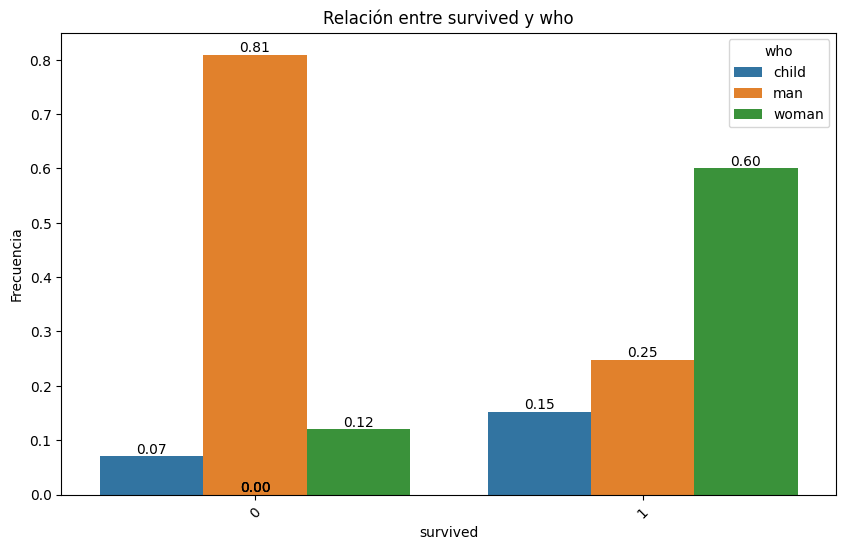

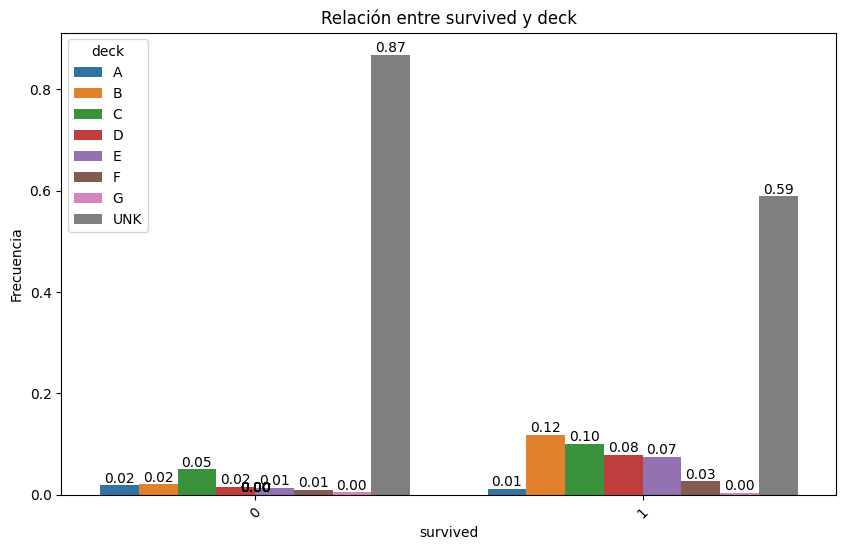

In [26]:
for feat in features_cat:
    bz.plot_categorical_relationship_fin(
        train_set,
        target,
        feat,
        show_values=True,
        relative_freq=True
    )

Procesado de categóricas

In [27]:
features_cat.remove("deck")
features_cat.append("deck_informed")

In [28]:
from sklearn.preprocessing import OrdinalEncoder

In [29]:
from sklearn.preprocessing import OrdinalEncoder

categories = [
    ["female", "male"],
    ["S", "C", "Q"],
    ["child", "woman", "man"]
]

encoder = OrdinalEncoder(categories=categories)

train_set[["sex", "embarked", "who"]] = encoder.fit_transform(
    train_set[["sex", "embarked", "who"]]
)

test_set[["sex", "embarked", "who"]] = encoder.transform(
    test_set[["sex", "embarked", "who"]]
)

In [30]:
train_set[["sex", "embarked", "who"]]

,sex,embarked,who
455,1.0,1.0,2.0
641,0.0,1.0,1.0
574,1.0,0.0,2.0
463,1.0,0.0,2.0
386,1.0,0.0,0.0
...,...,...,...
797,0.0,0.0,1.0
184,0.0,0.0,0.0
452,1.0,1.0,2.0
339,1.0,0.0,2.0


Procesado numérico

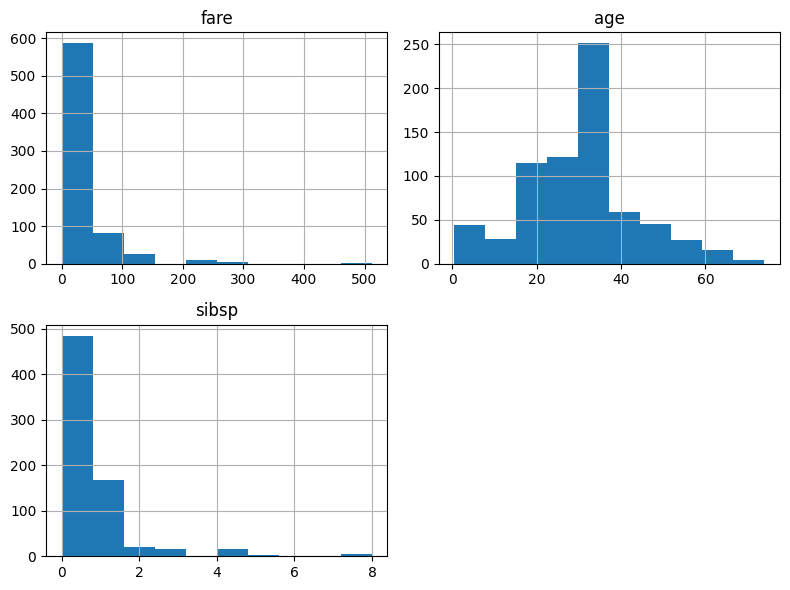

In [31]:
features_num = ["fare", "age", "sibsp"]

train_set[features_num].hist(
    figsize=(8, 6),
    bins=10
)

plt.tight_layout()
plt.show()

<Axes: >

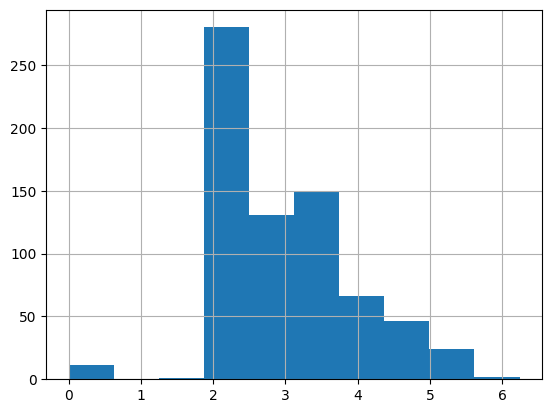

In [32]:
(train_set["fare"]+1).apply(np.log).hist()

<Axes: >

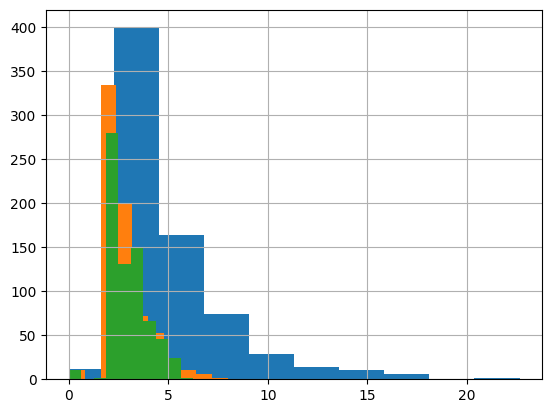

In [33]:
np.sqrt(train_set["fare"]).hist()   # Azul

np.cbrt(train_set["fare"]).hist()   # Naranja

np.log1p(train_set["fare"]).hist()  # Verde

<Axes: >

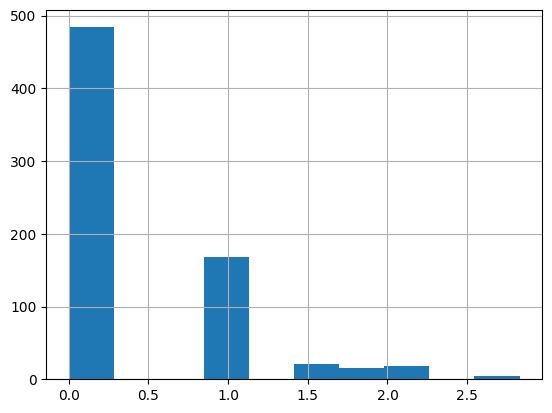

In [34]:
train_set["sibsp"].apply(np.sqrt).hist()

In [35]:
train_set

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,deck_informed
455,1,3,1.0,29.0,0,0,7.8958,1.0,Third,2.0,True,UNK,Cherbourg,yes,True,False
641,1,1,0.0,24.0,0,0,69.3000,1.0,First,1.0,False,B,Cherbourg,yes,True,True
574,0,3,1.0,16.0,0,0,8.0500,0.0,Third,2.0,True,UNK,Southampton,no,True,False
463,0,2,1.0,48.0,0,0,13.0000,0.0,Second,2.0,True,UNK,Southampton,no,True,False
386,0,3,1.0,1.0,5,2,46.9000,0.0,Third,0.0,False,UNK,Southampton,no,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
797,1,3,0.0,31.0,0,0,8.6833,0.0,Third,1.0,False,UNK,Southampton,yes,True,False
184,1,3,0.0,4.0,0,2,22.0250,0.0,Third,0.0,False,UNK,Southampton,yes,False,False
452,0,1,1.0,30.0,0,0,27.7500,1.0,First,2.0,True,C,Cherbourg,no,True,True
339,0,1,1.0,45.0,0,0,35.5000,0.0,First,2.0,True,UNK,Southampton,no,True,False


In [36]:
scaler = StandardScaler()
train_set[features_num] = scaler.fit_transform(train_set[features_num])
test_set[features_num]  = scaler.transform(test_set[features_num])

train_set.describe()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who
count,711.000000,711.000000,711.000000,7.110000e+02,7.110000e+02,711.000000,7.110000e+02,711.000000,711.000000
mean,0.379747,2.299578,0.644163,2.573344e-16,-7.495177e-18,0.381153,-1.249196e-16,0.362869,1.495077
std,0.485665,0.845193,0.479103,1.000704e+00,1.000704e+00,0.813363,1.000704e+00,0.637314,0.673160
min,0.000000,1.000000,0.000000,-2.235400e+00,-4.818043e-01,0.000000,-6.529641e-01,0.000000,0.000000
25%,0.000000,1.000000,0.000000,-5.908805e-01,-4.818043e-01,0.000000,-4.940679e-01,0.000000,1.000000
50%,0.000000,3.000000,1.000000,1.876526e-02,-4.818043e-01,0.000000,-3.620856e-01,0.000000,2.000000
75%,1.000000,3.000000,1.000000,3.997939e-01,4.440413e-01,0.000000,-2.911549e-02,1.000000,2.000000
max,1.000000,3.000000,1.000000,3.371817e+00,6.924961e+00,6.000000,9.657226e+00,2.000000,2.000000


In [37]:
test_set.describe()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,0.393258,2.359551,0.668539,0.024438,0.017528,0.387640,-0.035189,0.359551,1.573034
std,0.489851,0.791868,0.472066,0.941674,1.105212,0.782047,1.000104,0.633298,0.608557
min,0.000000,1.000000,0.000000,-2.210252,-0.481804,0.000000,-0.652964,0.000000,0.000000
25%,0.000000,2.000000,0.000000,-0.514675,-0.481804,0.000000,-0.492851,0.000000,1.000000
50%,0.000000,3.000000,1.000000,0.018765,-0.481804,0.000000,-0.376718,0.000000,2.000000
75%,1.000000,3.000000,1.000000,0.399794,0.444041,0.750000,-0.053642,1.000000,2.000000
max,1.000000,3.000000,1.000000,3.829051,6.924961,5.000000,9.657226,2.000000,2.000000


In [38]:
features_set_cat_1 = ["pclass", "who"]
features_set_cat_2 = features_cat


9. Modelado

In [39]:
features = features_num + features_set_cat_2

x_train = train_set[features]
y_train = train_set[target]

x_test = test_set[features]
y_test = test_set[target]

In [41]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=73
)

log_reg.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",73
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

              precision    recall  f1-score   support

           0       0.84      0.87      0.86       441
           1       0.78      0.73      0.75       270

    accuracy                           0.82       711
   macro avg       0.81      0.80      0.80       711
weighted avg       0.82      0.82      0.82       711



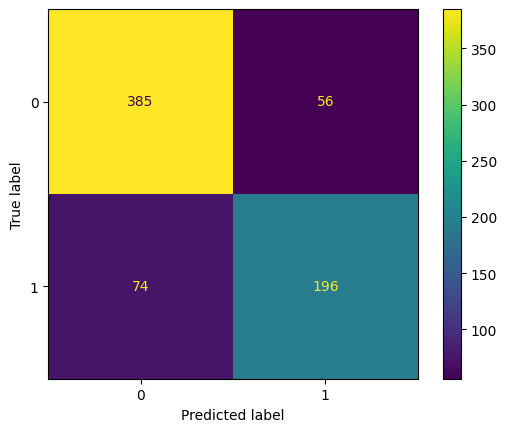

In [45]:
#paso de juan vers con mis variables

from sklearn.metrics import ConfusionMatrixDisplay, classification_report

def metrics_titanic(model, X, y_target):
    y_pred = model.predict(X)
    ConfusionMatrixDisplay.from_predictions(y_target, y_pred)
    print(classification_report(y_target, y_pred))


metrics_titanic(log_reg, x_train, y_train)

              precision    recall  f1-score   support

           0       0.82      0.93      0.87       108
           1       0.86      0.69      0.76        70

    accuracy                           0.83       178
   macro avg       0.84      0.81      0.82       178
weighted avg       0.83      0.83      0.83       178



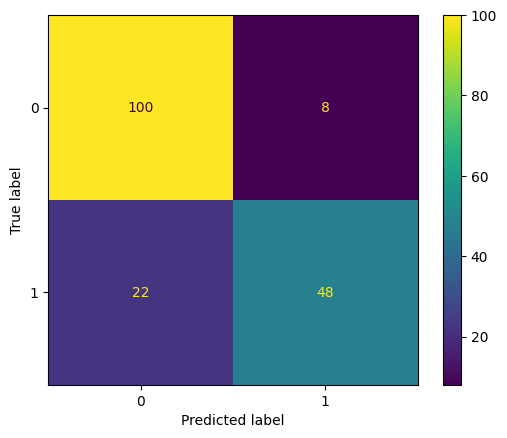

In [46]:
metrics_titanic (log_reg, x_test, y_test)

In [48]:
coeficientes = pd.DataFrame({
    "variable": x_train.columns,
    "coeficiente": log_reg.coef_[0]
})

coeficientes.sort_values(
    by="coeficiente",
    ascending=False
)

,variable,coeficiente
8,deck_informed,0.451192
5,embarked,0.272964
0,fare,0.003187
1,age,-0.301828
6,alone,-0.343592
2,sibsp,-0.626369
7,who,-0.975682
3,pclass,-1.011883
4,sex,-1.722960


<Axes: ylabel='variable'>

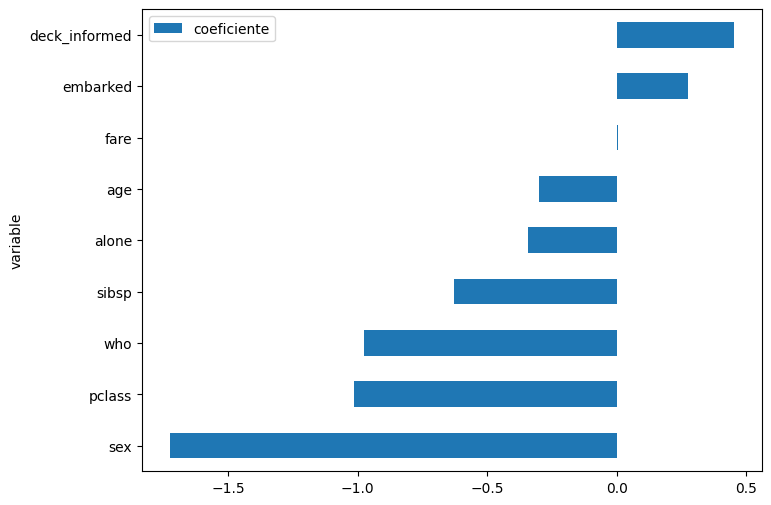

In [49]:
coeficientes.sort_values("coeficiente").plot(
    x="variable",
    y="coeficiente",
    kind="barh",
    figsize=(8,6)
)

In [53]:
from sklearn.metrics import roc_auc_score

y_prob = log_reg.predict_proba(x_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC AUC:", roc_auc)

ROC AUC: 0.8305555555555555


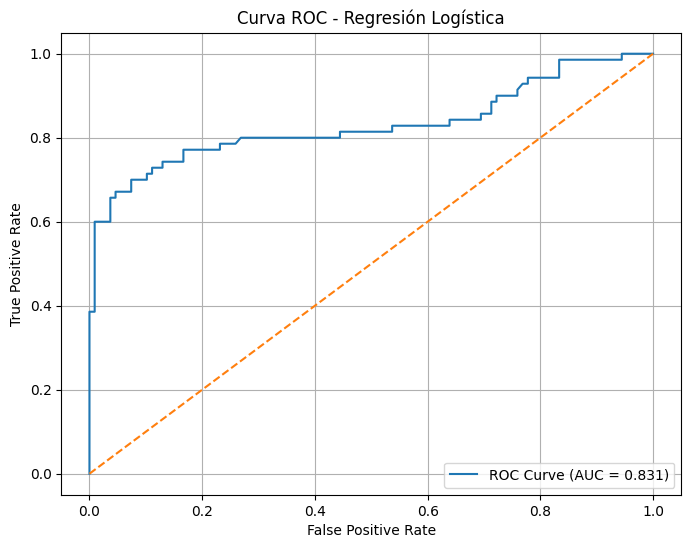

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades de la clase positiva (survived = 1)
y_prob = log_reg.predict_proba(x_test)[:, 1]

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calcular AUC
auc = roc_auc_score(y_test, y_prob)

# Gráfico
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")  # clasificador aleatorio

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()